In [1]:
# ================================
# Employee Turnover Analytics
# ================================

# Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from imblearn.over_sampling import SMOTE


In [14]:
# Load dataset
df = pd.read_csv("HR_comma_sep.csv")
print(df.head())


   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3     low  
4 

In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Basic info
print(df.info())

Missing values:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary        

In [4]:
print(df.describe())

       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834         0.716102        3.803054   
std              0.248631         0.171169        1.232592   
min              0.090000         0.360000        2.000000   
25%              0.440000         0.560000        3.000000   
50%              0.640000         0.720000        4.000000   
75%              0.820000         0.870000        5.000000   
max              1.000000         1.000000        7.000000   

       average_montly_hours  time_spend_company  Work_accident          left  \
count          14999.000000        14999.000000   14999.000000  14999.000000   
mean             201.050337            3.498233       0.144610      0.238083   
std               49.943099            1.460136       0.351719      0.425924   
min               96.000000            2.000000       0.000000      0.000000   
25%              156.000000            3.

## 2. Exploratory Data Analysis (EDA)

In [10]:
numeric_df = df.select_dtypes(include=[np.number])

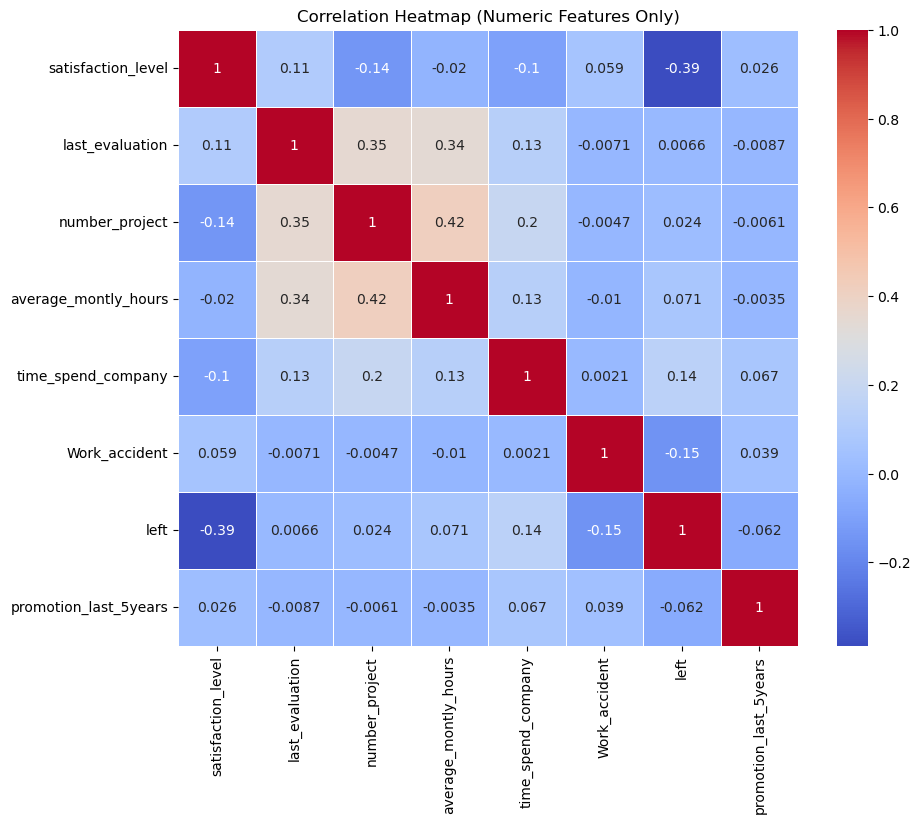

In [12]:
# 2.1 Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

## 2.2 Distribution 

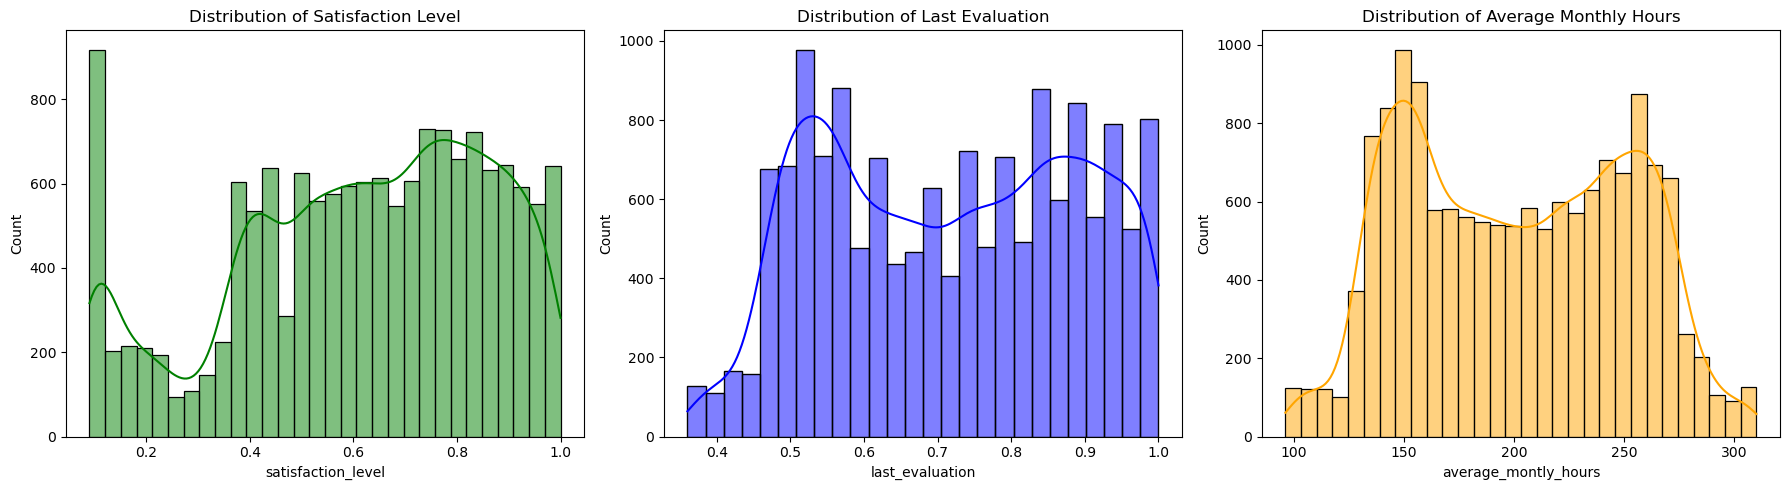

In [15]:

fig, axes = plt.subplots(1,3, figsize=(18,5)) 
sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0], color="green")
axes[0].set_title("Distribution of Satisfaction Level")
sns.histplot(df['last_evaluation'], kde=True, ax=axes[1], color="blue")
axes[1].set_title("Distribution of Last Evaluation")
sns.histplot(df['average_montly_hours'], kde=True, ax=axes[2], color="orange")
axes[2].set_title("Distribution of Average Monthly Hours")
plt.tight_layout()
plt.show()


## 2.3 Bar plot of project count vs left

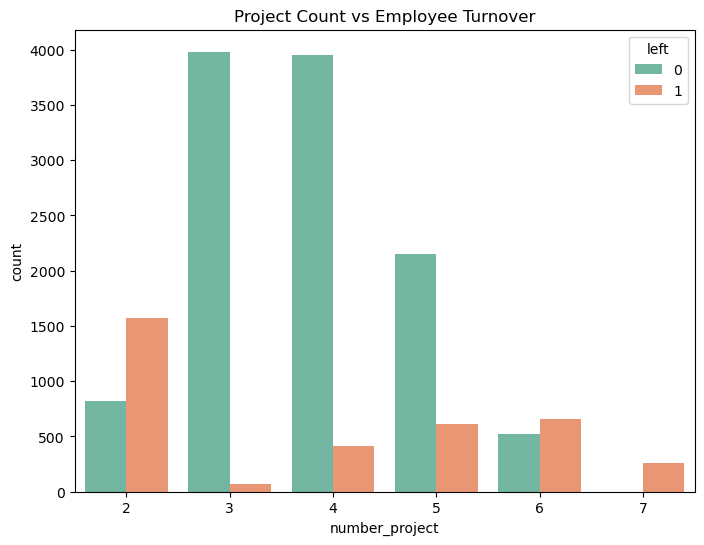

In [16]:
plt.figure(figsize=(8,6)) 
sns.countplot(x="number_project", hue="left", data=df, palette="Set2")
plt.title("Project Count vs Employee Turnover") 
plt.show()


# 3. Clustering (K-Means)

#### Select relevant columns

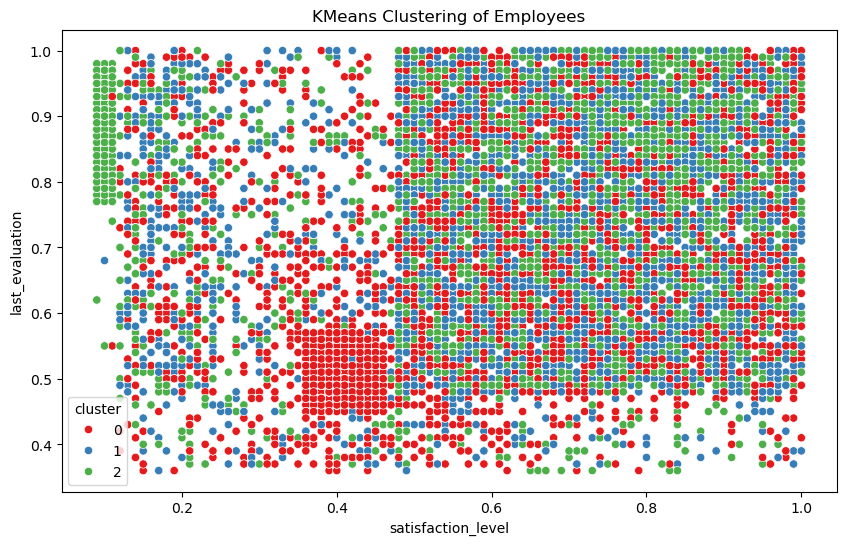

In [18]:
# KMeans clustering to identify employee segments
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data = df[['satisfaction_level', 'last_evaluation', 'average_montly_hours']]
df_cluster = cluster_data.copy()
df_cluster['cluster'] = kmeans.fit_predict(df_cluster[['satisfaction_level', 'last_evaluation', 'average_montly_hours']])
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cluster, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='Set1')
plt.title("KMeans Clustering of Employees")
plt.show()

# 4. Handling Class Imbalance with SMOTE

In [20]:
# Convert categorical to numerical
df_processed = pd.get_dummies(df, drop_first=True)
 

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      2286
           1       0.52      0.73      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000



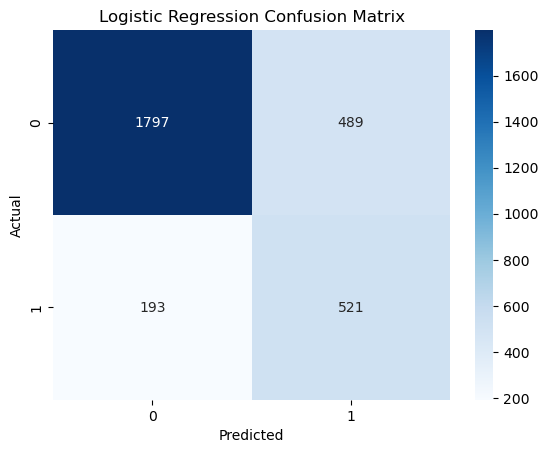

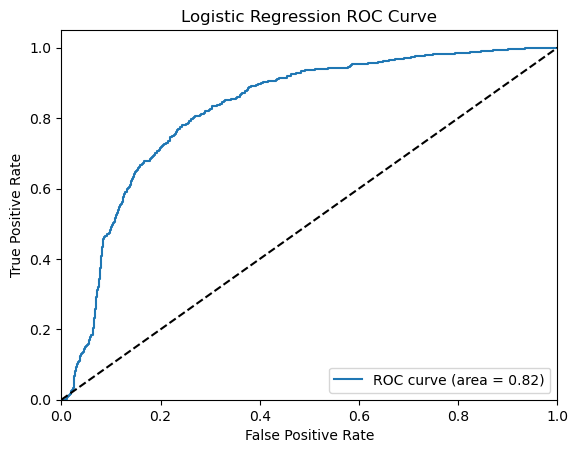

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



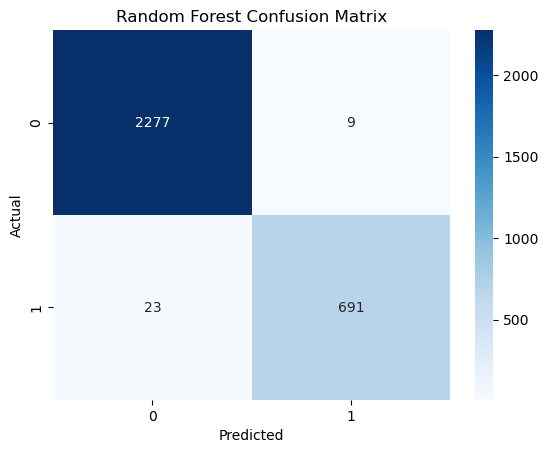

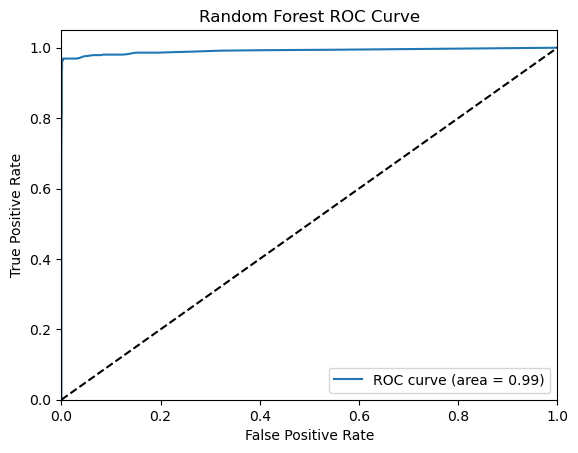

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2286
           1       0.92      0.94      0.93       714

    accuracy                           0.96      3000
   macro avg       0.95      0.96      0.95      3000
weighted avg       0.97      0.96      0.96      3000



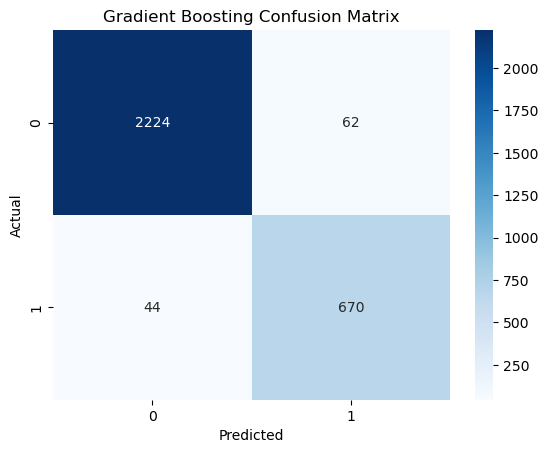

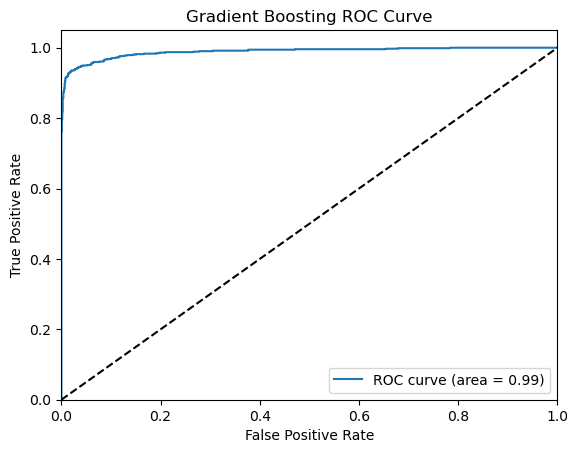

In [23]:
# Split data 
X = df_processed.drop("left", axis=1)
y = df_processed["left"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc="lower right")
        plt.show()
        

# 5. Model Training with 5-Fold Cross Validation

In [24]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}
# Cross-validation
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name} CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    

Logistic Regression CV Accuracy: 0.7952 ± 0.0313
Random Forest CV Accuracy: 0.9847 ± 0.0037
Gradient Boosting CV Accuracy: 0.9636 ± 0.0054


# 6. Model Evaluation

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      2286
           1       0.52      0.73      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000



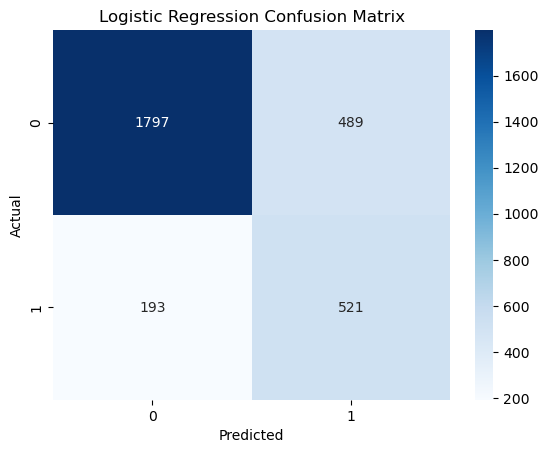

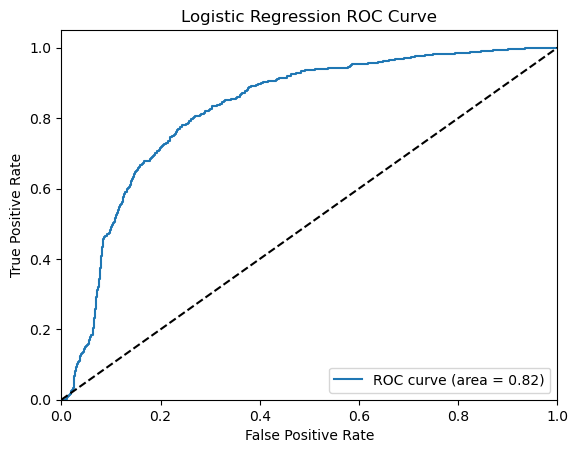

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



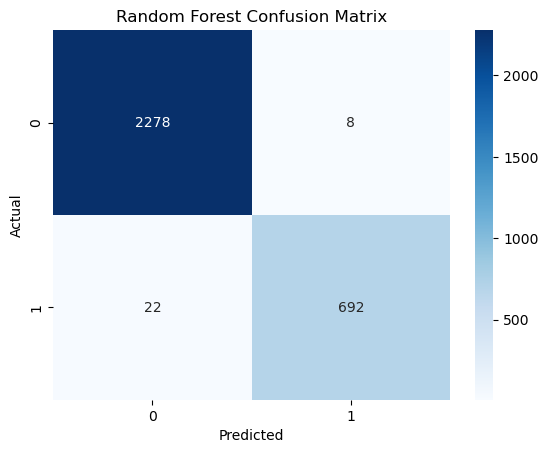

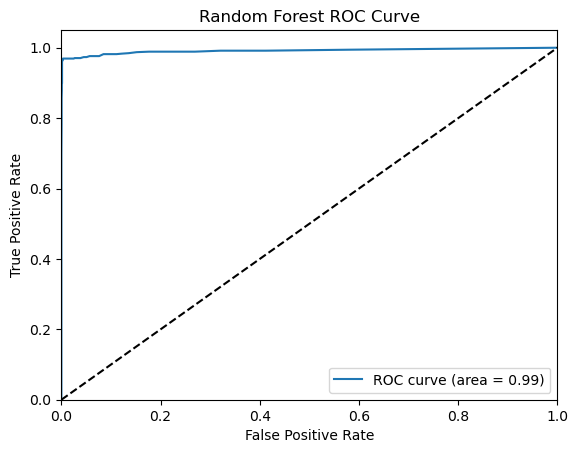

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2286
           1       0.92      0.94      0.93       714

    accuracy                           0.96      3000
   macro avg       0.95      0.96      0.95      3000
weighted avg       0.97      0.96      0.96      3000



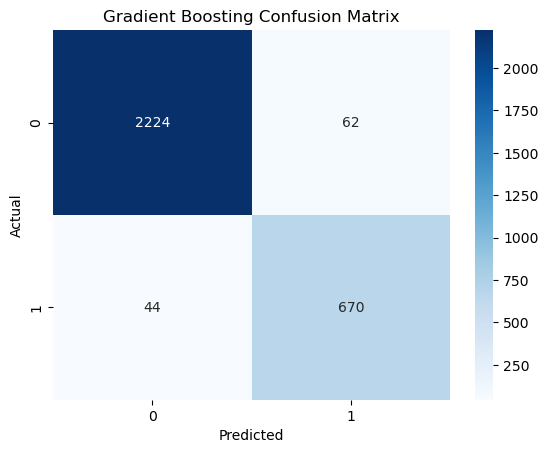

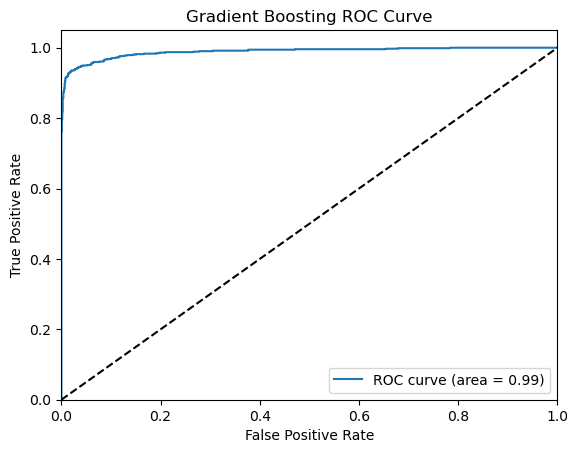

In [27]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc="lower right")
        plt.show()


# 7. Retention Strategies

In [31]:
# Choose best model 
best_model = GradientBoostingClassifier()
best_model.fit(X_train_res, y_train_res)

y_prob = best_model.predict_proba(X_test)[:,1]

# Categorize employees
def categorize(score):
    if score < 0.2: return "Safe Zone (Green)"
    elif score < 0.6: return "Low-Risk Zone (Yellow)"
    elif score < 0.9: return "Medium-Risk Zone (Orange)"
    else: return "High-Risk Zone (Red)"

# Convert y_prob into a Pandas Series so we can apply
df_test = X_test.copy()
df_test['turnover_risk'] = pd.Series(y_prob).apply(categorize)
print(df_test['turnover_risk'].value_counts())


turnover_risk
Safe Zone (Green)            423
High-Risk Zone (Red)         121
Low-Risk Zone (Yellow)        33
Medium-Risk Zone (Orange)     19
Name: count, dtype: int64


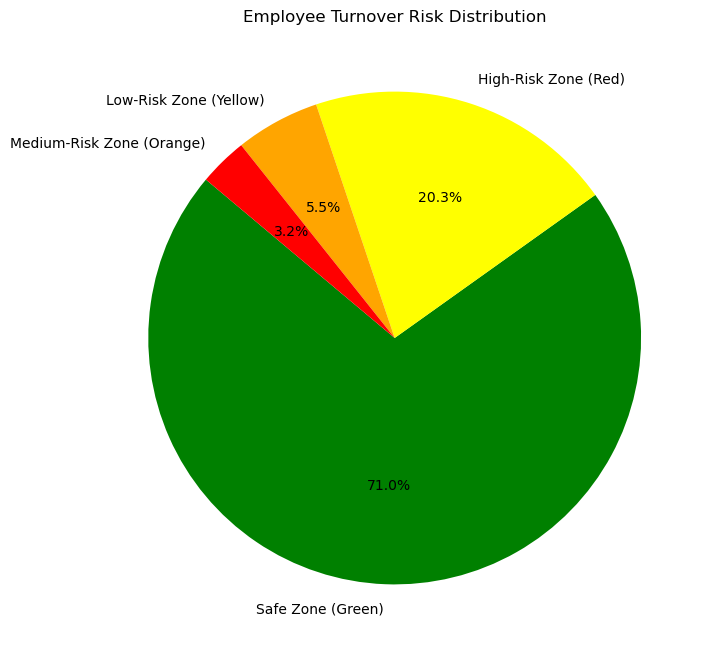

In [33]:
best_model = GradientBoostingClassifier()
best_model.fit(X_train_res, y_train_res)

y_prob = best_model.predict_proba(X_test)[:,1]

# Categorize employees
def categorize(score):
    if score < 0.2: return "Safe Zone (Green)"
    elif score < 0.6: return "Low-Risk Zone (Yellow)"
    elif score < 0.9: return "Medium-Risk Zone (Orange)"
    else: return "High-Risk Zone (Red)"
df_test = X_test.copy()
df_test['turnover_risk'] = pd.Series(y_prob).apply(categorize)
 # Count categories 
risk_counts = df_test['turnover_risk'].value_counts()
 # Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(
    risk_counts,
      labels=risk_counts.index,
        autopct='%1.1f%%', 
        colors=["green","yellow","orange","red"], 
        startangle=140 
        ) 
plt.title("Employee Turnover Risk Distribution")
plt.show()